<a href="https://colab.research.google.com/github/RamiroIsaJ/Aprendizaje_maquina_ML/blob/main/Taller_2_Algoritmos_Supervisados_RIJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

** Taller 2 de Métodos de Aprendizaje de Máquina **
* Por: Ramiro Isa Jara
* Fecha: 19 de julio de 2026

In [ ]:
# 1. Carga del dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import os
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import copy

os.chdir('..')

data = pd.read_csv('/content/drive/MyDrive/Aprendizaje_maquina_UTPL/Trabajos/winequality-red.csv', delimiter=';', encoding='unicode_escape')
print('Dataset loaded succesfully')

Dataset loaded succesfully


In [ ]:
# 2 (a). Analisis de las columnas del dataset
data.info(verbose=True)
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1577 entries, 0 to 1576
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1577 non-null   float64
 1   volatile acidity      1577 non-null   float64
 2   citric acid           1577 non-null   float64
 3   residual sugar        1577 non-null   float64
 4   chlorides             1577 non-null   float64
 5   free sulfur dioxide   1577 non-null   float64
 6   total sulfur dioxide  1577 non-null   float64
 7   density               1577 non-null   float64
 8   pH                    1577 non-null   float64
 9   sulphates             1577 non-null   float64
 10  alcohol               1577 non-null   float64
 11  quality               1577 non-null   object 
dtypes: float64(11), object(1)
memory usage: 148.0+ KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000
mean,8.286049,0.527372,0.270000,2.499524,0.087171,15.771084,46.266328,1.282299,3.312714,0.657356,10.427996
std,1.690263,0.178957,0.194807,1.271792,0.046961,10.332553,32.881900,1.579544,0.153244,0.170261,1.064281
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996720,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997800,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,10.032000,4.010000,2.000000,14.900000


In [ ]:
data=data.drop(['Unnamed: 0'], axis=1)

In [ ]:
# 2(b): revision de los datos
data.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
191,6.6,0.705,0.07,1.6,0.076,6.0,15.0,0.99620,3.44,0.58,10.7,low
321,11.0,0.300,0.58,2.1,0.054,7.0,19.0,0.99800,3.31,0.88,10.5,medium
707,6.7,0.460,0.24,1.7,0.077,18.0,34.0,0.99480,3.39,0.60,10.6,medium
514,8.4,0.310,0.29,3.1,0.194,14.0,26.0,0.99536,3.22,0.78,12.0,medium
1350,7.2,0.620,0.06,2.5,0.078,17.0,84.0,0.99746,3.51,0.53,9.7,low
927,10.9,0.320,0.52,1.8,0.132,17.0,44.0,0.99734,3.28,0.77,11.5,medium
583,7.3,0.510,0.18,2.1,0.070,12.0,28.0,0.99768,3.52,0.73,9.5,medium
639,7.5,0.510,0.02,1.7,0.084,13.0,31.0,0.99538,3.36,0.54,10.5,medium
791,8.5,0.470,0.27,1.9,0.058,18.0,38.0,0.99518,3.16,0.85,11.1,medium
15,11.3,0.360,0.66,2.4,0.123,3.0,8.0,0.99642,3.20,0.53,11.9,medium


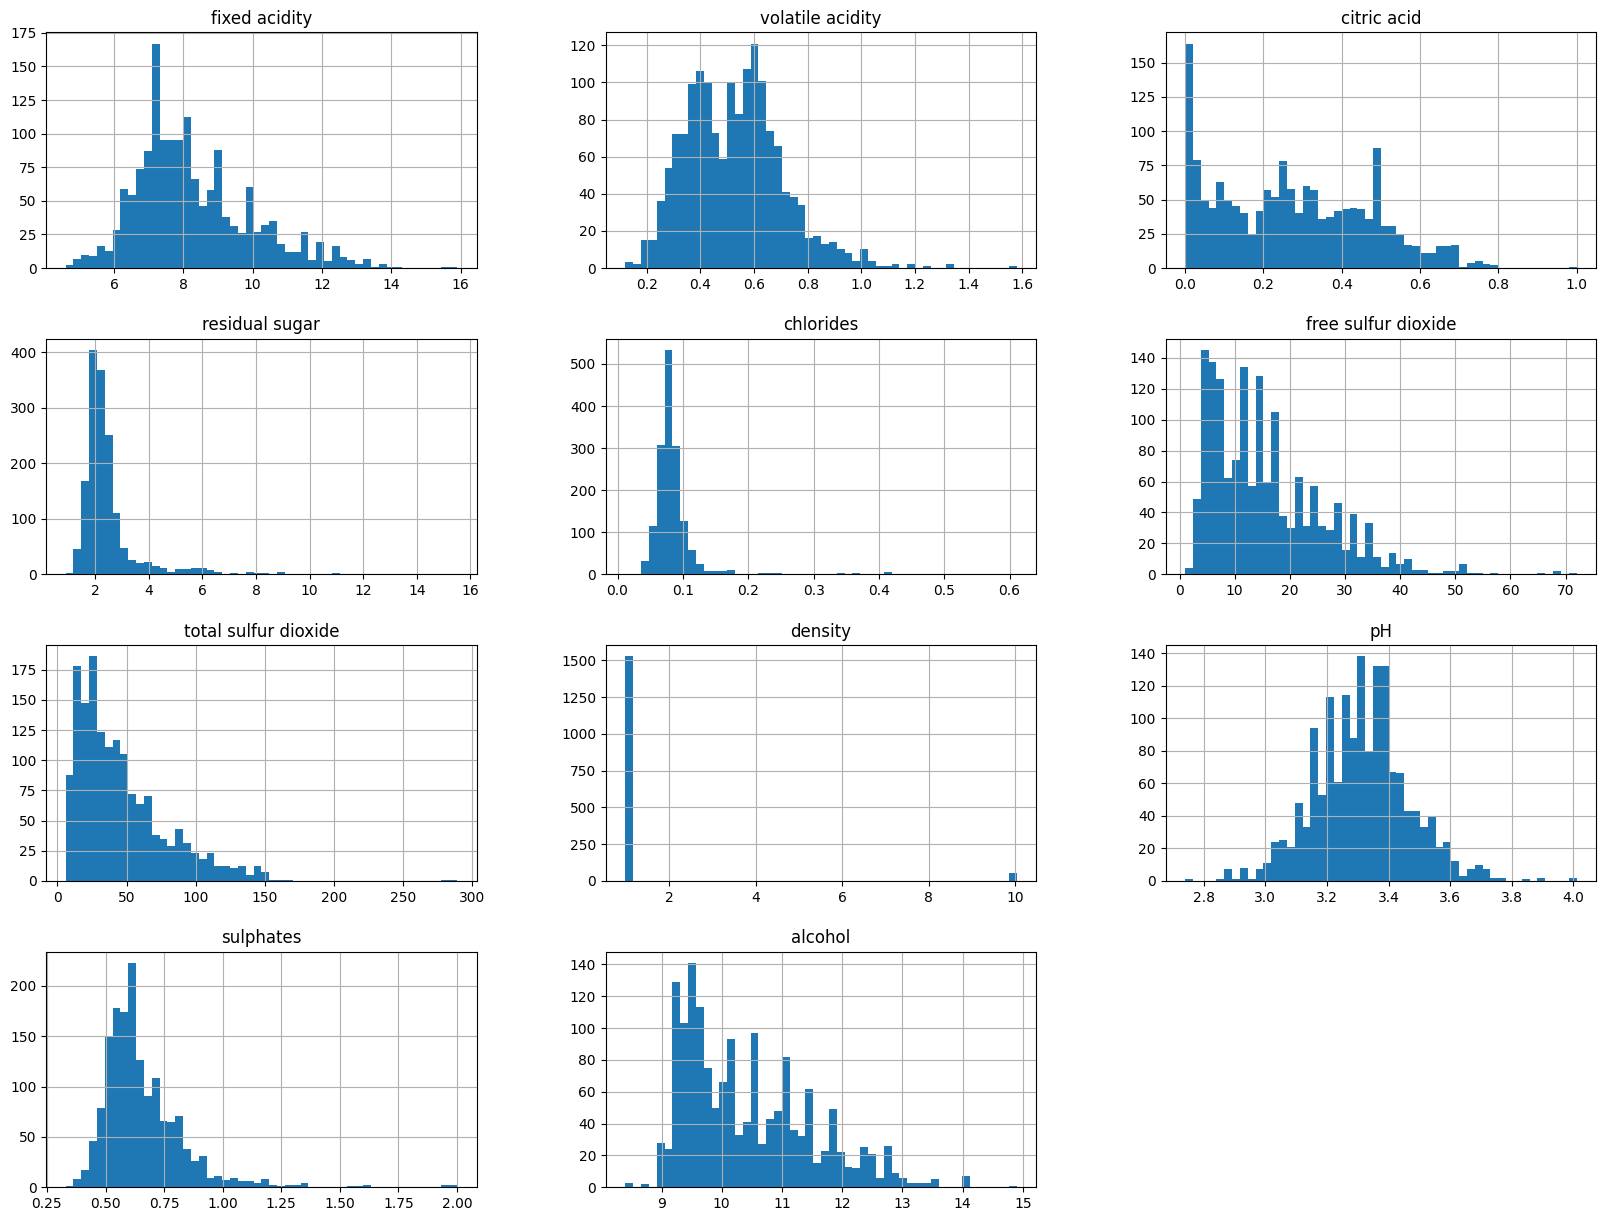

In [ ]:
# 2(c): graficas de los datos
data.hist(bins=50, figsize=(20,15))
plt.show()



### Tratamiento de los datos
Análisis de datos atípicos.

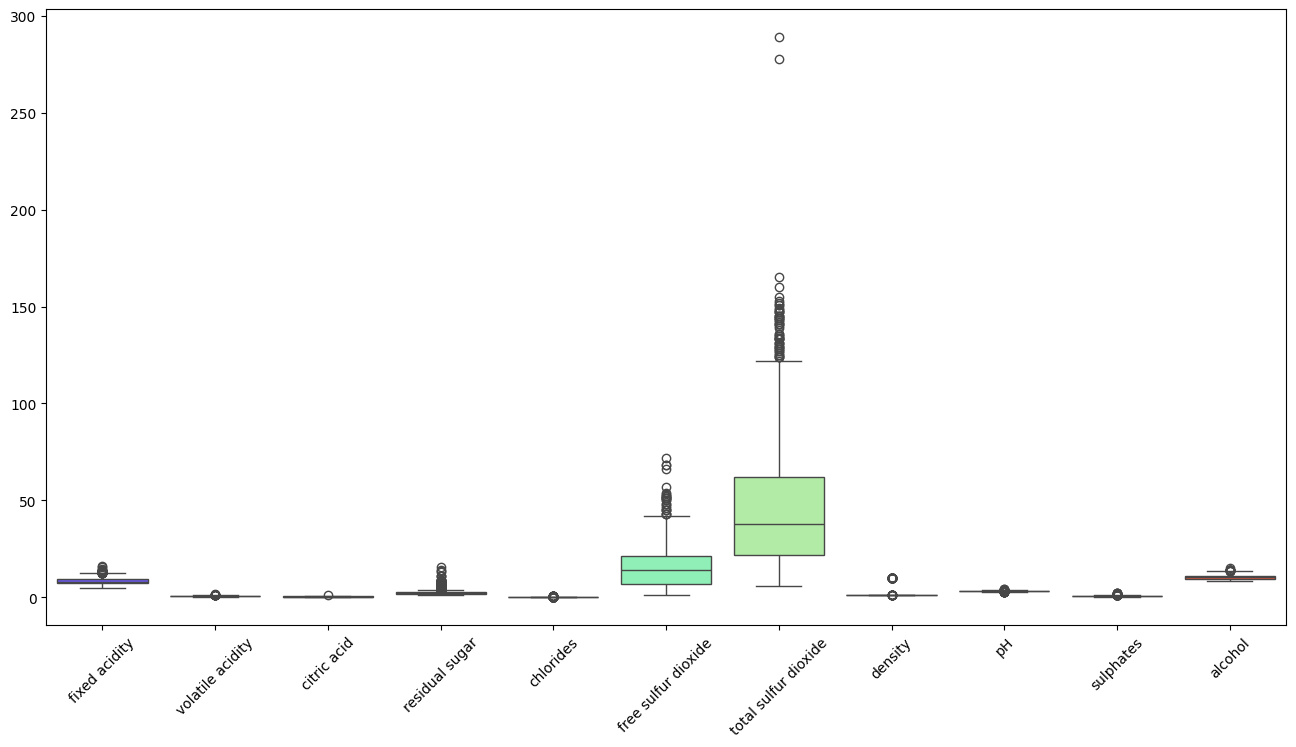

In [ ]:
plt.figure(figsize=(16,8))

sns.boxplot(data=data, palette='rainbow')

plt.xticks(rotation=45)
plt.show()

In [ ]:
# Seleccionar columnas numéricas
numeric_cols = data.select_dtypes(include=np.number).columns

# Aplicar capping con IQR
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Reemplazar outliers por límites
    data[col] = data[col].clip(lower, upper)

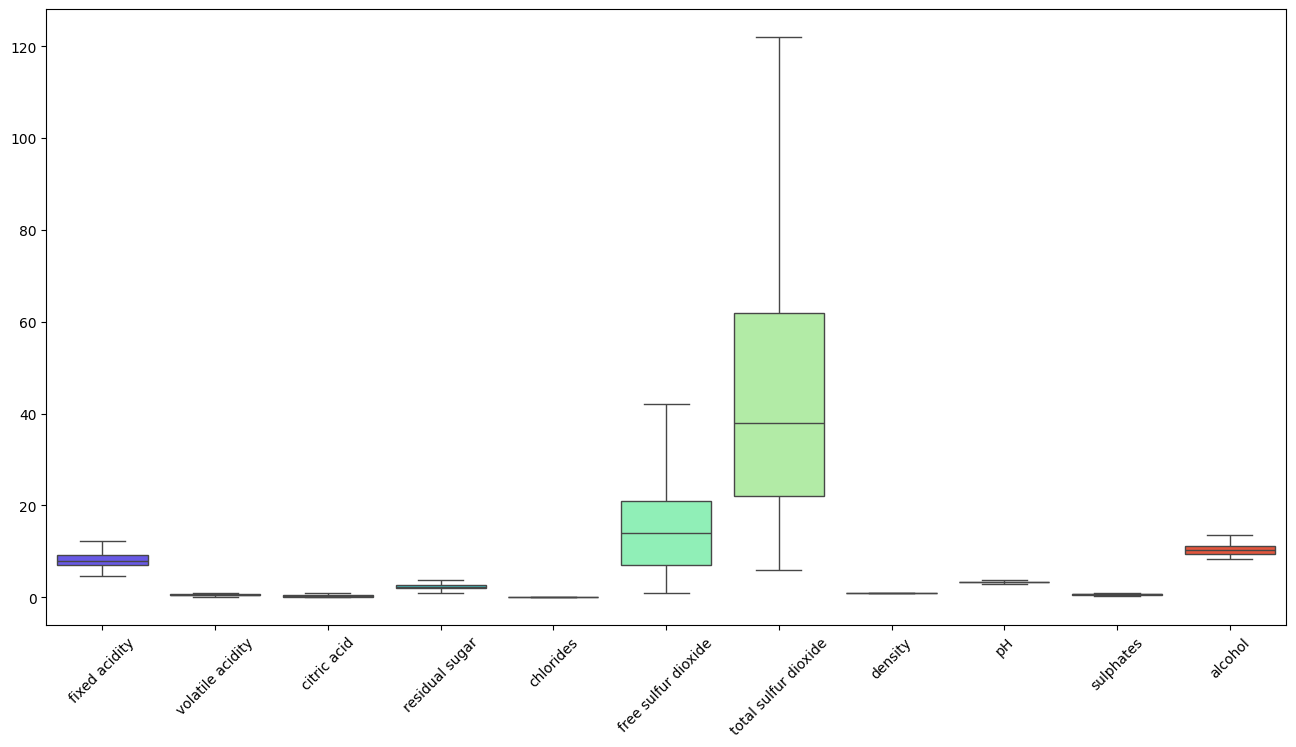

In [ ]:
plt.figure(figsize=(16,8))

sns.boxplot(data=data, palette='rainbow')

plt.xticks(rotation=45)
plt.show()

**-- Separar las variables**

### Feature engineering
Análisis de las variables predictoras para posterior aplicación en el modelo de Machine Learning.

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder_ = LabelEncoder()
data['quality'] = encoder_.fit_transform(data['quality'])

### Verificar las variables que tengan baja correlación

In [ ]:
correlation1 = data.corr(); correlation1['quality']

,quality
fixed acidity,0.092996
volatile acidity,-0.281909
citric acid,0.127973
residual sugar,0.004353
chlorides,-0.119271
free sulfur dioxide,-0.044355
total sulfur dioxide,-0.219073
density,-0.111941
pH,0.003630
sulphates,0.238149


### Analisis de variables con baja correlación en relación a la variable a predicir *quality*

In [ ]:
correlation1['quality'][(correlation1['quality'].abs() >= -0.1) & (correlation1['quality'].abs() <= 0.1)]

,quality
fixed acidity,0.092996
residual sugar,0.004353
free sulfur dioxide,-0.044355
pH,0.003630


In [ ]:
# Se crea un dataset alterno para comparar los resultados
data_alt = copy.deepcopy(data)

data_alt = data_alt.drop(columns=['fixed acidity', 'residual sugar',
                                  'free sulfur dioxide', 'pH'])
data_alt.head()

,volatile acidity,citric acid,chlorides,total sulfur dioxide,density,sulphates,alcohol,quality
0,0.315,0.40,0.079,6.0,0.99512,0.67,11.9,2
1,0.450,0.49,0.075,6.0,0.99690,0.63,10.4,1
2,0.450,0.49,0.075,6.0,0.99690,0.63,10.4,1
3,0.600,0.08,0.056,7.0,0.99286,0.37,13.0,1
4,0.580,0.16,0.120,7.0,0.99454,0.58,11.2,2


## División de las variables predictoras y a predecir por el modelo

In [ ]:
# Con el dataset Original
features = data.iloc[:, 0:11]
target = data.iloc[:, -1]
features.head(5)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,8.6,0.315,0.40,2.2,0.079,3.0,6.0,0.99512,3.27,0.67,11.9
1,12.2,0.450,0.49,1.4,0.075,3.0,6.0,0.99690,3.13,0.63,10.4
2,12.2,0.450,0.49,1.4,0.075,3.0,6.0,0.99690,3.13,0.63,10.4
3,8.0,0.600,0.08,2.6,0.056,3.0,7.0,0.99286,3.22,0.37,13.0
4,8.0,0.580,0.16,2.0,0.120,3.0,7.0,0.99454,3.22,0.58,11.2


In [ ]:
# Con el dataset Original
target.head(5)

,quality
0,2
1,1
2,1
3,1
4,2


In [ ]:
# Con el dataset Alternativo
features_alt = data_alt.iloc[:, 0:7]
target_alt = data_alt.iloc[:, -1]
features_alt.head(5)

,volatile acidity,citric acid,chlorides,total sulfur dioxide,density,sulphates,alcohol
0,0.315,0.40,0.079,6.0,0.99512,0.67,11.9
1,0.450,0.49,0.075,6.0,0.99690,0.63,10.4
2,0.450,0.49,0.075,6.0,0.99690,0.63,10.4
3,0.600,0.08,0.056,7.0,0.99286,0.37,13.0
4,0.580,0.16,0.120,7.0,0.99454,0.58,11.2


In [ ]:
# Con el dataset alternativo
target_alt.head(5)

,quality
0,2
1,1
2,1
3,1
4,2


## Normalización de datos


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler1 = StandardScaler()
features = scaler1.fit_transform(features)

scaler2 = StandardScaler()
features_alt = scaler2.fit_transform(features_alt)

**--- División del conjunto de entranamiento y prueba**

In [ ]:
from sklearn.model_selection import train_test_split

train_X, test_X, train_Y, test_Y = train_test_split(features, target, test_size=0.3, random_state=42, shuffle=True)

train_Xa, test_Xa, train_Ya, test_Ya = train_test_split(features_alt, target_alt, test_size=0.3, random_state=42, shuffle=True)

**--- Balanceo de los datos**

In [ ]:
# balanceo solo con los datos de entrenamiento

from imblearn.over_sampling import SMOTE
from collections import Counter

over_sampler = SMOTE(k_neighbors=5)
train_XB, train_YB = over_sampler.fit_resample(train_X, train_Y)
print(f"Training target statistics: {Counter(train_YB)}")


Training target statistics: Counter({2: 568, 1: 568, 0: 568})


In [ ]:
train_XBa, train_YBa = over_sampler.fit_resample(train_Xa, train_Ya)
print(f"Training target statistics: {Counter(train_YBa)}")

Training target statistics: Counter({2: 568, 1: 568, 0: 568})


## Algoritmo 1: Árboles de decisión

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
dtree_model = DecisionTreeClassifier(random_state=42)

param_RSgrid = {
    'max_depth': [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
    'criterion': ['gini', 'entropy']
}
random_search_trees = RandomizedSearchCV(dtree_model, param_RSgrid, cv=5, return_train_score=False).fit(train_XB, train_YB)

### Evaluación de los modelos entrenados y selección del mejor modelo

In [ ]:
cvresRSGrid = random_search_trees.cv_results_
for mean_score, params in zip(cvresRSGrid["mean_test_score"], cvresRSGrid["params"]):
    print(mean_score, params)

# print best parameter after tuning
print(random_search_trees.best_params_)

print(random_search_trees.best_score_)

print(random_search_trees.best_estimator_)

0.7993151630153528 {'max_depth': 40, 'criterion': 'gini'}
0.7975470070726237 {'max_depth': 40, 'criterion': 'entropy'}
0.7969708469898223 {'max_depth': 10, 'criterion': 'gini'}
0.7993151630153528 {'max_depth': 50, 'criterion': 'gini'}
0.7969639468690701 {'max_depth': 15, 'criterion': 'entropy'}
0.7975470070726237 {'max_depth': 50, 'criterion': 'entropy'}
0.7993151630153528 {'max_depth': 30, 'criterion': 'gini'}
0.7899189235811626 {'max_depth': 10, 'criterion': 'entropy'}
0.7993151630153528 {'max_depth': 35, 'criterion': 'gini'}
0.7975470070726237 {'max_depth': 25, 'criterion': 'entropy'}
{'max_depth': 40, 'criterion': 'gini'}
0.7993151630153528
DecisionTreeClassifier(max_depth=40, random_state=42)


In [ ]:
# Selección del mejor modelo
best_model_tree = random_search_trees.best_estimator_

predict_Y = best_model_tree.predict(test_X)
print(confusion_matrix(test_Y, predict_Y))
print(classification_report(test_Y, predict_Y))

[[  1   1   3]
 [  0 152  60]
 [ 14  66 177]]
              precision    recall  f1-score   support

           0       0.07      0.20      0.10         5
           1       0.69      0.72      0.71       212
           2       0.74      0.69      0.71       257

    accuracy                           0.70       474
   macro avg       0.50      0.54      0.51       474
weighted avg       0.71      0.70      0.70       474



Text(50.722222222222214, 0.5, 'Real values')

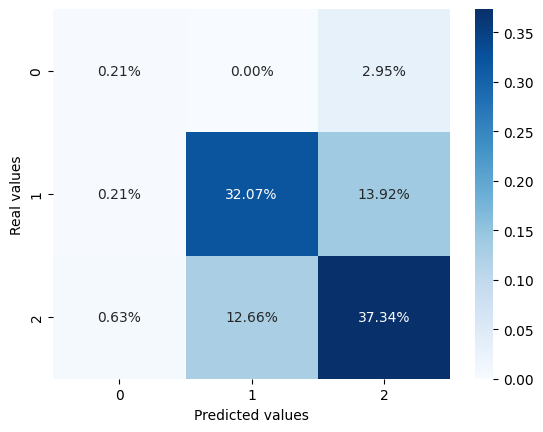

In [ ]:
matrix = confusion_matrix(predict_Y, test_Y)
ax = sns.heatmap(matrix/np.sum(matrix), annot=True, fmt='.2%', cmap='Blues')
ax.set_xlabel('Predicted values')
ax.set_ylabel('Real values')

## Conclusión 1

Utilizando el conjunto de datos original, se obtiene un valor muy bajo de precisión en el *F1-score* para la clase 0 correspondiente a 'medium'

In [ ]:
# utilización del conjunto de datos alternativo

random_search_trees_a = RandomizedSearchCV(dtree_model, param_RSgrid, cv=5, return_train_score=False).fit(train_XBa, train_YBa)

In [ ]:
cvresRSGrida = random_search_trees_a.cv_results_
for mean_scorea, paramsa in zip(cvresRSGrida["mean_test_score"], cvresRSGrida["params"]):
    print(mean_scorea, paramsa)

# print best parameter after tuning
print(random_search_trees_a.best_params_)

print(random_search_trees_a.best_score_)

print(random_search_trees_a.best_estimator_)

0.7957771260997066 {'max_depth': 30, 'criterion': 'gini'}
0.7922649646368811 {'max_depth': 40, 'criterion': 'entropy'}
0.7957771260997066 {'max_depth': 35, 'criterion': 'gini'}
0.7957771260997066 {'max_depth': 25, 'criterion': 'gini'}
0.7776039330688287 {'max_depth': 10, 'criterion': 'gini'}
0.7922649646368811 {'max_depth': 25, 'criterion': 'entropy'}
0.7957771260997066 {'max_depth': 50, 'criterion': 'gini'}
0.7957771260997066 {'max_depth': 40, 'criterion': 'gini'}
0.7922649646368811 {'max_depth': 30, 'criterion': 'entropy'}
0.6895566672416769 {'max_depth': 2, 'criterion': 'entropy'}
{'max_depth': 30, 'criterion': 'gini'}
0.7957771260997066
DecisionTreeClassifier(max_depth=30, random_state=42)


In [ ]:
# Selección del mejor modelo
best_model_tree_a = random_search_trees_a.best_estimator_

predict_Ya = best_model_tree_a.predict(test_Xa)
print(confusion_matrix(test_Ya, predict_Ya))
print(classification_report(test_Ya, predict_Ya))

[[  2   0   3]
 [  0 157  55]
 [ 15  67 175]]
              precision    recall  f1-score   support

           0       0.12      0.40      0.18         5
           1       0.70      0.74      0.72       212
           2       0.75      0.68      0.71       257

    accuracy                           0.70       474
   macro avg       0.52      0.61      0.54       474
weighted avg       0.72      0.70      0.71       474



Text(50.722222222222214, 0.5, 'Real values')

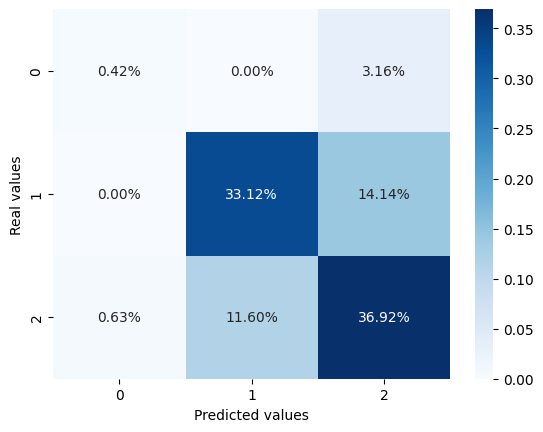

In [ ]:
matrixa = confusion_matrix(predict_Ya, test_Ya)
ax = sns.heatmap(matrixa/np.sum(matrixa), annot=True, fmt='.2%', cmap='Blues')
ax.set_xlabel('Predicted values')
ax.set_ylabel('Real values')

## Conclusión 2

Utilizando el conjunto de datos alternativo (utlizando feature engineering), se mejora levemente la precisión en el *F1-score* para la clase 0 correspondiente a 'medium'. De todas formas, sigue siendo un valor muy bajo de precisión.

## Algoritmo 2: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

param_RSgrid_rf = {
    'max_depth': [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
    'criterion': ['gini', 'entropy'],
    'n_estimators': [100, 200, 300, 400, 500, 600]
}
random_search_rf = RandomizedSearchCV(rf_model, param_RSgrid_rf, cv=5, return_train_score=False).fit(train_XB, train_YB)

In [ ]:
cvresRSGridrf = random_search_rf.cv_results_
for mean_score, params in zip(cvresRSGridrf["mean_test_score"], cvresRSGrid["params"]):
    print(mean_score, params)

# print best parameter after tuning
print(random_search_rf.best_params_)

print(random_search_rf.best_score_)

print(random_search_rf.best_estimator_)

0.8497774711057444 {'max_depth': 40, 'criterion': 'gini'}
0.8556477488356047 {'max_depth': 40, 'criterion': 'entropy'}
0.8574141797481456 {'max_depth': 10, 'criterion': 'gini'}
0.8556598240469209 {'max_depth': 50, 'criterion': 'gini'}
0.859756770743488 {'max_depth': 15, 'criterion': 'entropy'}
0.8016698292220112 {'max_depth': 50, 'criterion': 'entropy'}
0.85683284457478 {'max_depth': 30, 'criterion': 'gini'}
0.7999033983094704 {'max_depth': 10, 'criterion': 'entropy'}
0.7382801449025358 {'max_depth': 35, 'criterion': 'gini'}
0.8544833534586855 {'max_depth': 25, 'criterion': 'entropy'}
{'n_estimators': 500, 'max_depth': 25, 'criterion': 'gini'}
0.859756770743488
RandomForestClassifier(max_depth=25, n_estimators=500, random_state=42)


In [ ]:
# Selección del mejor modelo
best_model_rf = random_search_rf.best_estimator_

predict_Yrf = best_model_rf.predict(test_X)
print(confusion_matrix(test_Y, predict_Yrf))
print(classification_report(test_Y, predict_Yrf))

[[  1   0   4]
 [  0 169  43]
 [ 13  51 193]]
              precision    recall  f1-score   support

           0       0.07      0.20      0.11         5
           1       0.77      0.80      0.78       212
           2       0.80      0.75      0.78       257

    accuracy                           0.77       474
   macro avg       0.55      0.58      0.55       474
weighted avg       0.78      0.77      0.77       474



Text(50.722222222222214, 0.5, 'Real values')

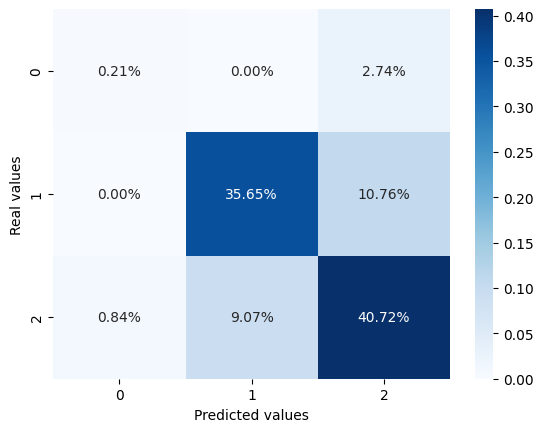

In [ ]:
matrixrf = confusion_matrix(predict_Yrf, test_Y)
ax = sns.heatmap(matrixrf/np.sum(matrixrf), annot=True, fmt='.2%', cmap='Blues')
ax.set_xlabel('Predicted values')
ax.set_ylabel('Real values')

In [ ]:
# utilización del conjunto de datos alternativo

random_search_rf_a = RandomizedSearchCV(rf_model, param_RSgrid_rf, cv=5, return_train_score=False).fit(train_XBa, train_YBa)

In [ ]:
cvresRSGridrfa = random_search_rf_a.cv_results_
for mean_score, params in zip(cvresRSGridrfa["mean_test_score"], cvresRSGrid["params"]):
    print(mean_score, params)

# print best parameter after tuning
print(random_search_rf_a.best_params_)

print(random_search_rf_a.best_score_)

print(random_search_rf_a.best_estimator_)

0.8421390374331551 {'max_depth': 40, 'criterion': 'gini'}
0.7329981024667932 {'max_depth': 40, 'criterion': 'entropy'}
0.839208211143695 {'max_depth': 10, 'criterion': 'gini'}
0.840969466965672 {'max_depth': 50, 'criterion': 'gini'}
0.845666724167673 {'max_depth': 15, 'criterion': 'entropy'}
0.831580127652234 {'max_depth': 50, 'criterion': 'entropy'}
0.840969466965672 {'max_depth': 30, 'criterion': 'gini'}
0.8491892358116268 {'max_depth': 10, 'criterion': 'entropy'}
0.8409660169052959 {'max_depth': 35, 'criterion': 'gini'}
0.8016612040710711 {'max_depth': 25, 'criterion': 'entropy'}
{'n_estimators': 500, 'max_depth': 15, 'criterion': 'gini'}
0.8491892358116268
RandomForestClassifier(max_depth=15, n_estimators=500, random_state=42)


In [ ]:
# Selección del mejor modelo
best_model_rf_a = random_search_rf_a.best_estimator_

predict_Yarf = best_model_rf_a.predict(test_Xa)
print(confusion_matrix(test_Ya, predict_Yarf))
print(classification_report(test_Ya, predict_Yarf))

[[  2   0   3]
 [  0 177  35]
 [ 18  49 190]]
              precision    recall  f1-score   support

           0       0.10      0.40      0.16         5
           1       0.78      0.83      0.81       212
           2       0.83      0.74      0.78       257

    accuracy                           0.78       474
   macro avg       0.57      0.66      0.58       474
weighted avg       0.80      0.78      0.79       474



Text(50.722222222222214, 0.5, 'Real values')

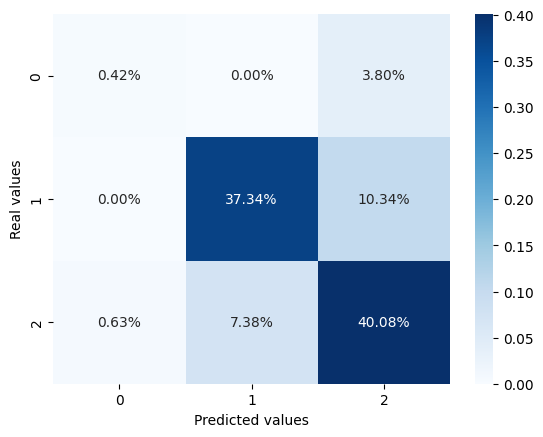

In [ ]:
matrixarf = confusion_matrix(predict_Yarf, test_Ya)
ax = sns.heatmap(matrixarf/np.sum(matrixarf), annot=True, fmt='.2%', cmap='Blues')
ax.set_xlabel('Predicted values')
ax.set_ylabel('Real values')

## Conclusiones a partir de los resultados

- Con el conjunto original, se tiene una clasificación deficiente. Los resultados son similares a los obtenidos por el algoritmo de árboles de decisión.

- Con el conjunto alternativo, usando random forest, se mejora las métricas de clasificación con respecto a todas las pruebas anteriores. De todas formas, la métrica f1-score para la clase 0 es muy baja.

## Algoritmo 3: KNN (K vecinos cercanos)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

param_RSgrid_knn = {
    'n_neighbors': [2, 4, 5, 6, 8, 10, 15, 20],
}
random_search_knn = RandomizedSearchCV(knn_model, param_RSgrid_knn, cv=5, return_train_score=False).fit(train_XB, train_YB)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [ ]:
cvresRSGridknn = random_search_knn.cv_results_
for mean_score, params in zip(cvresRSGridknn["mean_test_score"], cvresRSGridknn["params"]):
    print(mean_score, params)

# print best parameter after tuning
print(random_search_knn.best_params_)

print(random_search_knn.best_score_)

print(random_search_knn.best_estimator_)

0.6930688287045024 {'n_neighbors': 2}
0.6860186303260307 {'n_neighbors': 4}
0.6748766603415559 {'n_neighbors': 5}
0.6813334483353459 {'n_neighbors': 6}
0.6713489736070382 {'n_neighbors': 8}
0.6613886493013628 {'n_neighbors': 10}
0.6531671554252199 {'n_neighbors': 15}
0.6455407969639468 {'n_neighbors': 20}
{'n_neighbors': 2}
0.6930688287045024
KNeighborsClassifier(n_neighbors=2)


In [ ]:
# Selección del mejor modelo
best_model_knn = random_search_knn.best_estimator_

predict_Yknn = best_model_rf.predict(test_X)
print(confusion_matrix(test_Y, predict_Yknn))
print(classification_report(test_Y, predict_Yknn))

[[  1   0   4]
 [  0 169  43]
 [ 13  51 193]]
              precision    recall  f1-score   support

           0       0.07      0.20      0.11         5
           1       0.77      0.80      0.78       212
           2       0.80      0.75      0.78       257

    accuracy                           0.77       474
   macro avg       0.55      0.58      0.55       474
weighted avg       0.78      0.77      0.77       474



Text(50.722222222222214, 0.5, 'Real values')

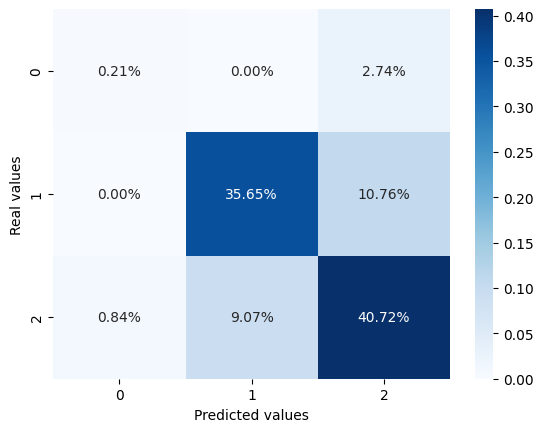

In [ ]:
matrixknn = confusion_matrix(predict_Yknn, test_Y)
ax = sns.heatmap(matrixknn/np.sum(matrixknn), annot=True, fmt='.2%', cmap='Blues')
ax.set_xlabel('Predicted values')
ax.set_ylabel('Real values')

In [ ]:
# utilización del conjunto de datos alternativo

random_search_knn_a = RandomizedSearchCV(knn_model, param_RSgrid_knn, cv=5, return_train_score=False).fit(train_XBa, train_YBa)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [ ]:
cvresRSGridknna = random_search_knn_a.cv_results_
for mean_score, params in zip(cvresRSGridknna["mean_test_score"], cvresRSGridknna["params"]):
    print(mean_score, params)

# print best parameter after tuning
print(random_search_knn_a.best_params_)

print(random_search_knn_a.best_score_)

print(random_search_knn_a.best_estimator_)

0.7013041228221494 {'n_neighbors': 2}
0.7001276522339142 {'n_neighbors': 4}
0.6713696739692944 {'n_neighbors': 5}
0.678412972227014 {'n_neighbors': 6}
0.6766758668276696 {'n_neighbors': 8}
0.6631723305157841 {'n_neighbors': 10}
0.642014835259617 {'n_neighbors': 15}
0.6349836122132138 {'n_neighbors': 20}
{'n_neighbors': 2}
0.7013041228221494
KNeighborsClassifier(n_neighbors=2)


In [ ]:
# Selección del mejor modelo
best_model_knn_a = random_search_knn_a.best_estimator_

predict_Yaknn = best_model_knn_a.predict(test_Xa)
print(confusion_matrix(test_Ya, predict_Yaknn))
print(classification_report(test_Ya, predict_Yaknn))

[[  4   1   0]
 [  4 176  32]
 [ 63 120  74]]
              precision    recall  f1-score   support

           0       0.06      0.80      0.11         5
           1       0.59      0.83      0.69       212
           2       0.70      0.29      0.41       257

    accuracy                           0.54       474
   macro avg       0.45      0.64      0.40       474
weighted avg       0.64      0.54      0.53       474



Text(50.722222222222214, 0.5, 'Real values')

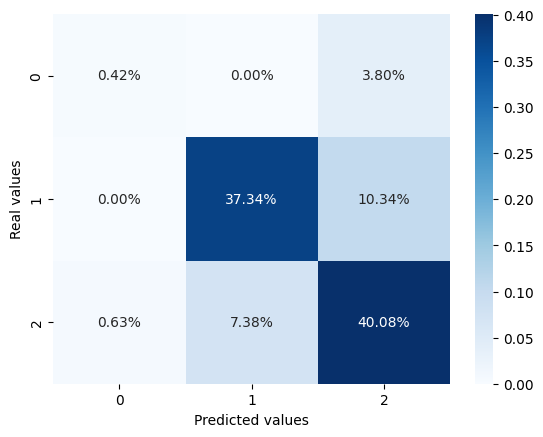

In [ ]:
matrixaknn = confusion_matrix(predict_Yaknn, test_Ya)
ax = sns.heatmap(matrixaknn/np.sum(matrixaknn), annot=True, fmt='.2%', cmap='Blues')
ax.set_xlabel('Predicted values')
ax.set_ylabel('Real values')

## Conclusiones a partir de los resultados

- Con los datos originales, y con distintos valores para el parámetro de vecino no se mejoran los resultados de clasificación.

- Con el conjunto de datos alternativo, la clasificación es muy imprecisa comparando con los resultados preliminares.

- Con este algoritmo, se han obtenido métricas de clasificación muy bajas.

## Algoritmo 4: SVM (Máquinas de soporte vectorial)

In [ ]:
from sklearn.svm import SVC

svm_model = SVC()

param_RSgrid_svm = [
    # Kernel lineal
    {
        "kernel": ["linear"],
        "C": [0.01, 0.1, 1, 5, 10, 20, 50, 100]
    },

    # Kernel RBF
    {
        "kernel": ["rbf"],
        "C": [0.01, 0.1, 1, 5, 10, 20, 50, 100],
        "gamma": ["scale", "auto", 0.0001, 0.001, 0.01, 0.1, 1]

    }
]

random_search_svm = RandomizedSearchCV(svm_model, param_RSgrid_svm, cv=5, return_train_score=False).fit(train_XB, train_YB)

In [ ]:
cvresRSGridsvm = random_search_svm.cv_results_
for mean_score, params in zip(cvresRSGridsvm["mean_test_score"], cvresRSGridsvm["params"]):
    print(mean_score, params)

# print best parameter after tuning
print(random_search_svm.best_params_)

print(random_search_svm.best_score_)

print(random_search_svm.best_estimator_)

0.7799620493358634 {'kernel': 'rbf', 'gamma': 0.01, 'C': 5}
0.7212730722787649 {'kernel': 'rbf', 'gamma': 0.001, 'C': 5}
0.7277298602725548 {'kernel': 'rbf', 'gamma': 0.001, 'C': 10}
0.6637536656891495 {'kernel': 'rbf', 'gamma': 'auto', 'C': 0.01}
0.8186751768155942 {'kernel': 'rbf', 'gamma': 0.1, 'C': 10}
0.6772451267897187 {'kernel': 'rbf', 'gamma': 0.0001, 'C': 5}
0.7200948766603416 {'kernel': 'rbf', 'gamma': 0.0001, 'C': 50}
0.7435708124892185 {'kernel': 'linear', 'C': 10}
0.7423960669311713 {'kernel': 'linear', 'C': 5}
0.8204450577885112 {'kernel': 'rbf', 'gamma': 0.1, 'C': 50}
{'kernel': 'rbf', 'gamma': 0.1, 'C': 50}
0.8204450577885112
SVC(C=50, gamma=0.1)


In [ ]:
# Selección del mejor modelo
best_model_svm = random_search_svm.best_estimator_

predict_Ysvm = best_model_svm.predict(test_X)
print(confusion_matrix(test_Y, predict_Ysvm))
print(classification_report(test_Y, predict_Ysvm))

[[  1   1   3]
 [  1 160  51]
 [  8  63 186]]
              precision    recall  f1-score   support

           0       0.10      0.20      0.13         5
           1       0.71      0.75      0.73       212
           2       0.78      0.72      0.75       257

    accuracy                           0.73       474
   macro avg       0.53      0.56      0.54       474
weighted avg       0.74      0.73      0.74       474



Text(50.722222222222214, 0.5, 'Real values')

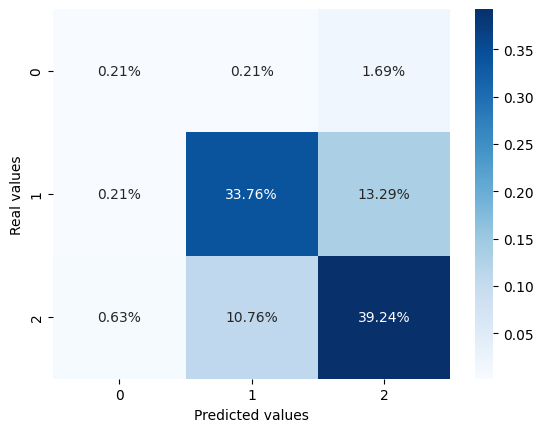

In [ ]:
matrixsvm = confusion_matrix(predict_Ysvm, test_Y)
ax = sns.heatmap(matrixsvm/np.sum(matrixsvm), annot=True, fmt='.2%', cmap='Blues')
ax.set_xlabel('Predicted values')
ax.set_ylabel('Real values')

In [ ]:
# utilización del conjunto de datos alternativo

random_search_svm_a = RandomizedSearchCV(svm_model, param_RSgrid_svm, cv=5, return_train_score=False).fit(train_XBa, train_YBa)

In [ ]:
cvresRSGridsvma = random_search_svm_a.cv_results_
for mean_score, params in zip(cvresRSGridsvma["mean_test_score"], cvresRSGridsvma["params"]):
    print(mean_score, params)

# print best parameter after tuning
print(random_search_svm_a.best_params_)

print(random_search_svm_a.best_score_)

print(random_search_svm_a.best_estimator_)

0.3656908745903053 {'kernel': 'rbf', 'gamma': 0.0001, 'C': 0.1}
0.3651026392961877 {'kernel': 'rbf', 'gamma': 0.001, 'C': 0.01}
0.8139899948249093 {'kernel': 'rbf', 'gamma': 0.1, 'C': 50}
0.7869949974124546 {'kernel': 'rbf', 'gamma': 0.01, 'C': 100}
0.7159875797826463 {'kernel': 'rbf', 'gamma': 0.0001, 'C': 50}
0.6702035535621873 {'kernel': 'rbf', 'gamma': 0.0001, 'C': 5}
0.7940244954286699 {'kernel': 'rbf', 'gamma': 'auto', 'C': 1}
0.8087062273589787 {'kernel': 'rbf', 'gamma': 'auto', 'C': 50}
0.3656908745903053 {'kernel': 'rbf', 'gamma': 0.0001, 'C': 0.01}
0.8075245816801793 {'kernel': 'rbf', 'gamma': 0.1, 'C': 20}
{'kernel': 'rbf', 'gamma': 0.1, 'C': 50}
0.8139899948249093
SVC(C=50, gamma=0.1)


In [ ]:
# Selección del mejor modelo
best_model_svm_a = random_search_svm_a.best_estimator_

predict_Yasvm = best_model_svm_a.predict(test_Xa)
print(confusion_matrix(test_Ya, predict_Yasvm))
print(classification_report(test_Ya, predict_Yasvm))

[[  1   2   2]
 [  2 163  47]
 [ 13  71 173]]
              precision    recall  f1-score   support

           0       0.06      0.20      0.10         5
           1       0.69      0.77      0.73       212
           2       0.78      0.67      0.72       257

    accuracy                           0.71       474
   macro avg       0.51      0.55      0.52       474
weighted avg       0.73      0.71      0.72       474



Text(50.722222222222214, 0.5, 'Real values')

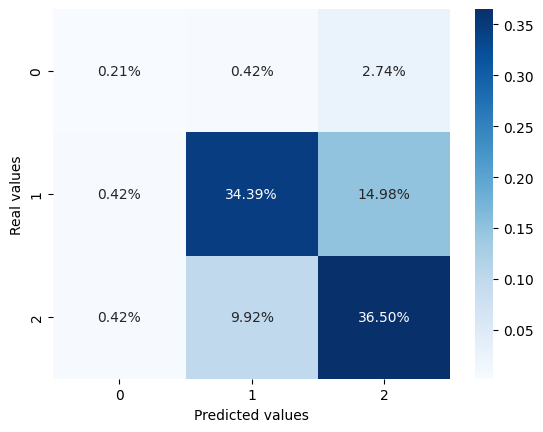

In [ ]:
matrixasvm = confusion_matrix(predict_Yasvm, test_Ya)
ax = sns.heatmap(matrixasvm/np.sum(matrixasvm), annot=True, fmt='.2%', cmap='Blues')
ax.set_xlabel('Predicted values')
ax.set_ylabel('Real values')

## Conclusiones a partir de los resultados

- Con los datos originales, y con distintos valores para los parámetros de *kernel* y *gamma* no se mejoran los resultados de clasificación.

- Con el conjunto de datos alternativo, la clasificación es muy imprecisa comparando con los resultados preliminares.

- Con este algoritmo, se han obtenido métricas de clasificación relativamente baja con respecto a las anteriores pruebas.

- El mejor algoritmo durante estas pruebas realizadas ha sido DecisionTrees.

- Hay que considerar la calidad de los datos influyen en el rendimiento de los algoritmos.